# EDA of the PassivUK temperature time series dataset

In [1]:
import os
from datetime import datetime
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd

from temp_data_plot_functions import set_up_figure, plot_hot_water, plot_room_temp, plot_tariff

## Load data

In [2]:
data_path = "data/PSTData5"
temperature_files = [f for f in glob(os.path.join(data_path, "*.csv")) if "Events" not in f]
events_files = [f for f in glob(os.path.join(data_path, "*_Events_*_*.csv"))]

In [3]:
# House:
house_index = 7
house_id = temperature_files[house_index].split("/")[-1].split("_")[0]
house_df = pd.read_csv(temperature_files[house_index])

In [4]:
house_id

'30055'

# Preprocessing

In [5]:
# Convert time to datetime
house_df["Datetime"] = [datetime.strptime(t, '%Y-%m-%d %H:%M') for t in house_df['Time (UTC)'].values]

In [6]:
house_temp_df =  house_df.reindex(columns = ["Room temperature (Zone 1) (°C)",
                                             "Setpoint temperature (Zone 1) (°C)",
                                             "Flow temperature setpoint (°C)",
                                             "Flow temperature (°C)",
                                             "Return temperature (°C)",
                                             "External temperature (°C)"])            
house_temp_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Room temperature (Zone 1) (°C),21698.0,21.327556,0.758071,18.4,20.8,21.3,21.7,27.3
Setpoint temperature (Zone 1) (°C),21742.0,19.152516,3.699804,8.0,17.0,21.0,21.0,24.0
Flow temperature setpoint (°C),21742.0,48.357373,7.852327,23.0,43.0,52.0,55.0,55.0
Flow temperature (°C),21742.0,32.528194,11.083715,8.0,25.0,32.0,40.0,58.0
Return temperature (°C),21742.0,28.638028,11.797794,7.0,18.0,29.0,36.0,58.0
External temperature (°C),21742.0,5.308021,3.211037,-2.0,3.0,5.0,7.0,15.0


In [7]:
house_df

,Time (UTC),Room temperature (Zone 1) (°C),Room temperature (Zone 2) (°C),Setpoint temperature (Zone 1) (°C),Setpoint temperature (Zone 2) (°C),Override (Zone 1) (0/1),Override (Zone 2) (0/1),Space heating (0/1),Zone 1 heating (0/1),Zone 2 heating (0/1),...,Immersion call (0/1),Immersion status (0/1),Hot water setpoint (°C),Flow temperature (°C),Return temperature (°C),Defrost status (0/1),Ecoheat (0/1),Tariff rate (p/kWh),External temperature (°C),Datetime
0,2025-12-23 12:15,21.5,20.6,24.0,24.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,40.0,15.0,10.0,0.0,0.0,NaN,5.0,2025-12-23 12:15:00
1,2025-12-23 12:20,21.5,20.6,24.0,24.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,60.0,15.0,10.0,0.0,0.0,NaN,5.0,2025-12-23 12:20:00
2,2025-12-23 12:25,21.5,20.6,24.0,24.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,60.0,15.0,10.0,0.0,0.0,NaN,5.0,2025-12-23 12:25:00
3,2025-12-23 12:30,21.5,20.6,24.0,24.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,60.0,15.0,10.0,0.0,0.0,NaN,5.0,2025-12-23 12:30:00
4,2025-12-23 12:35,21.5,20.6,24.0,24.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,60.0,14.0,10.0,0.0,0.0,NaN,5.0,2025-12-23 12:35:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21737,2026-03-08 23:40,21.7,22.7,21.0,21.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,40.0,31.0,19.0,0.0,0.0,23.51,10.0,2026-03-08 23:40:00
21738,2026-03-08 23:45,21.7,22.7,21.0,21.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,40.0,30.0,18.0,0.0,0.0,23.51,10.0,2026-03-08 23:45:00
21739,2026-03-08 23:50,21.5,22.7,21.0,21.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,40.0,29.0,18.0,0.0,0.0,23.51,10.0,2026-03-08 23:50:00
21740,2026-03-08 23:55,21.5,22.4,21.0,21.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,40.0,28.0,17.0,0.0,0.0,23.51,10.0,2026-03-08 23:55:00


# Plot house time series

In [8]:
num_days = int(len(house_df)/(12*24))
num_weeks = int(num_days/7)

In [9]:
datapoints_in_week = (12*24)*7
datapoints_in_day = (12*24)

### Plot by week

In [10]:
def calc_num_weeks_and_days(df, datapoints_in_hour):
    """Calculate the number of weeks and days in the dataset; as well as the number of datapoints in each week and day
    
    Args:
        df (Dataframe): data for plotting
        datapoints_in_hour (int): number of datapoints (i.e. rows in dataframe) per hour
    
    Returns:
        num_weeks (int): number of weeks covered by dataset
        num_days (int): number of days covered by dataset
        datapoints_in_week (int): number of datapoints (i.e. rows in dataframe) per week
        datapoints_in_day (int): number of datapoints (i.e. rows in dataframe) per day
    
    """
    datapoints_in_day = datapoints_in_hour*24
    datapoints_in_week = datapoints_in_day*7
    num_days = int(len(df)/(datapoints_in_day))
    num_weeks = int(num_days/7)
    
    return num_weeks, num_days, datapoints_in_week, datapoints_in_day


def configure_plotting_vars(df, plot_weeks, week_to_plot):
    """Configure number of plots and required offset
    
    Args:
        df (Dataframe): data for plotting
        plot_weeks (Bool): whether or not we are plotting weeks, if True: weeks if False: days
        week_to_plot (index): either index of week to plot data for (must be <num_weeks)
            OR None indicating all weeks should be plotted
    
    Returns:
        plots (list): List of indexes to use to configure plots, length indicates number of plots to produce
        offset (int): offset to be used to plot days for a specific week; otherwise set to 0 as no offset needed
        slice_length (int): length of each slice of data (i.e. number of rows covered)
            for each plot (either equal to a week or a day)
    """

    # Calculate amount of data
    num_weeks, num_days, datapoints_in_week, datapoints_in_day = calc_num_weeks_and_days(df, 12)

    if plot_weeks and week_to_plot is not None:
        plots = [week_to_plot] # num_to_plot = 1  # Plot one week
        offset = 0
    elif not plot_weeks and week_to_plot is not None:
        plots = range(7)  # Plot seven days
        offset = datapoints_in_week*week_to_plot  # Offset only needed if plotting days for a specific week
    else:  # NOT using week_to_plot (i.e. want all days or all weeks in dataset)
        plots = range(num_weeks) if plot_weeks else range(num_days)
        offset = 0
    
    slice_length = datapoints_in_week if plot_weeks else datapoints_in_day

    return plots, offset, slice_length

In [11]:
def plot_temp_data(df, house_id, plot_weeks, week_to_plot=None):
    """Plot the temperature data by either week or day

    Args:
        df (Dataframe): data for plotting
        house_id (str): id of house ot plot
        plot_weeks (Bool): whether or not we are plotting weeks, if True: weeks if False: days
        week_to_plot (index, optional): either index of week to plot data for (must be <num_weeks)
            OR None indicating all weeks should be plotted
            Default: None (i.e. plot all weeks/days in data)

    Returns:
        Plots of the temperature data by week or day 
            either for all weeks/days or those corresponding to a specified week
    """
    # Configure number of plots and required offset
    plots, offset, slice_length = configure_plotting_vars(df, plot_weeks, week_to_plot)

    for i in plots:
        # Slice by time (week or day)
        start_index = offset + i*slice_length
        end_index = offset + i*slice_length + slice_length

        # Get data
        dates = df["Datetime"][start_index:end_index]
        room_temp = df["Room temperature (Zone 1) (°C)"][start_index:end_index]
        user_setpoint = df["Setpoint temperature (Zone 1) (°C)"][start_index:end_index]
        flow_temp = df["Flow temperature (°C)"][start_index:end_index]
        hot_water_temp = df["Hot water temperature (°C)"][start_index:end_index]
        hot_water_setpoint = df["Hot water setpoint (°C)"][start_index:end_index]
        try: 
            ext_temp = df["External temperature (°C)"][start_index:end_index]
        except:  # noqa: E722
            ext_temp = None
        tariff = df["Tariff rate (p/kWh)"][start_index:end_index]

        # Make subfigs
        temp_plot, hot_water_plot, tariff_plot = set_up_figure(df, house_id, plot_weeks, week_to_plot, dates, start_index, end_index, i)

        # Plot on subfigs
        plot_room_temp(temp_plot, dates, room_temp, user_setpoint, flow_temp, ext_temp)
        plot_hot_water(hot_water_plot, dates, hot_water_temp, hot_water_setpoint, flow_temp)
        plot_tariff(df, tariff_plot, dates, tariff)

        plt.show()

In [12]:
num_days = int(len(house_df)/(12*24))
num_weeks = int(num_days/7)
num_weeks

10

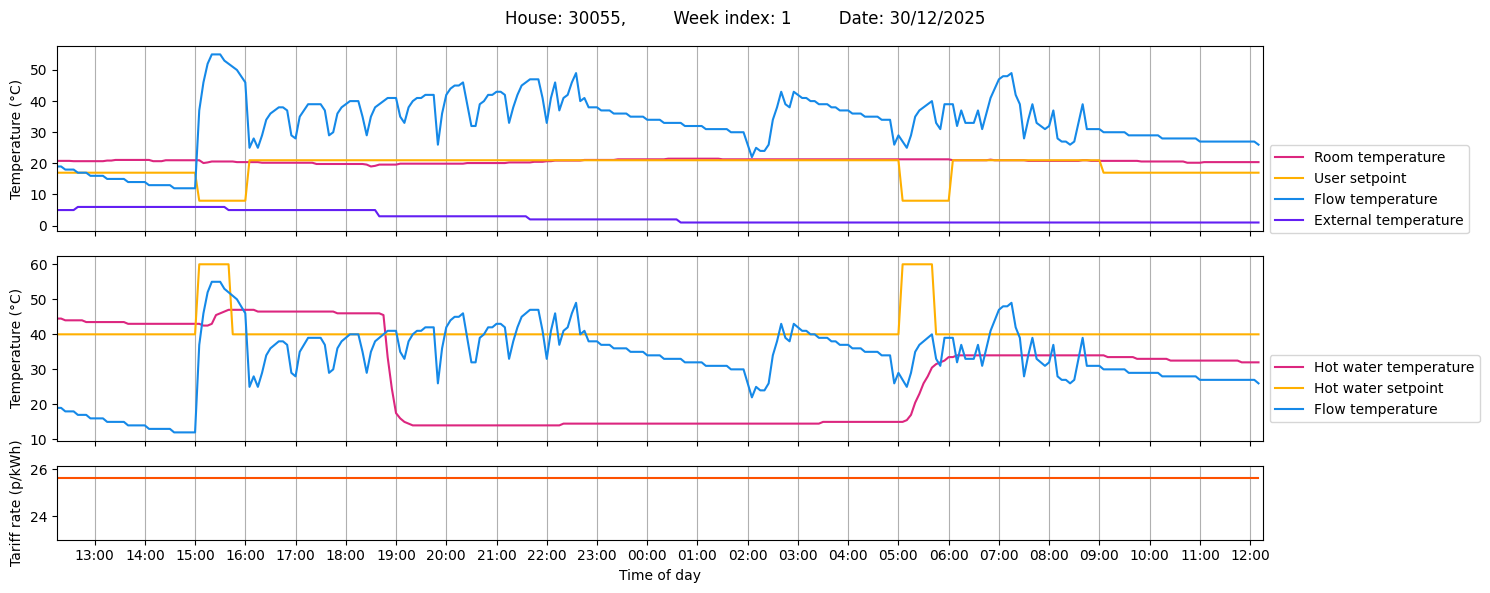

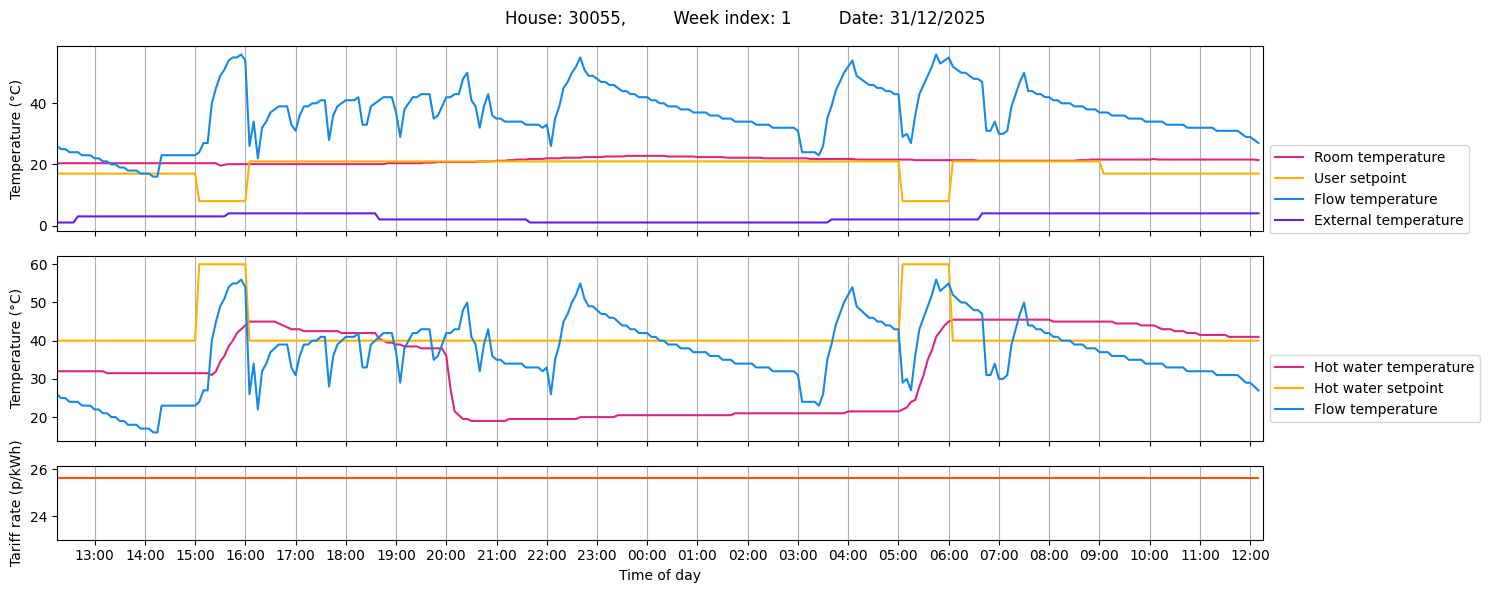

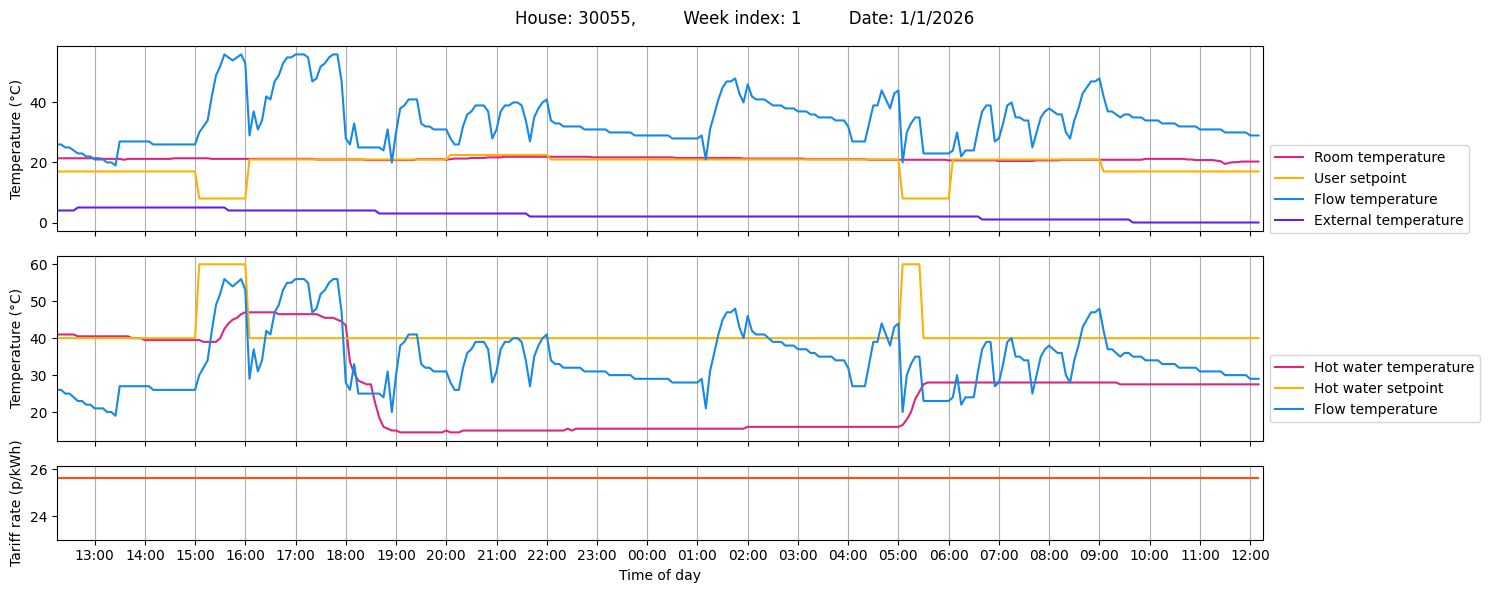

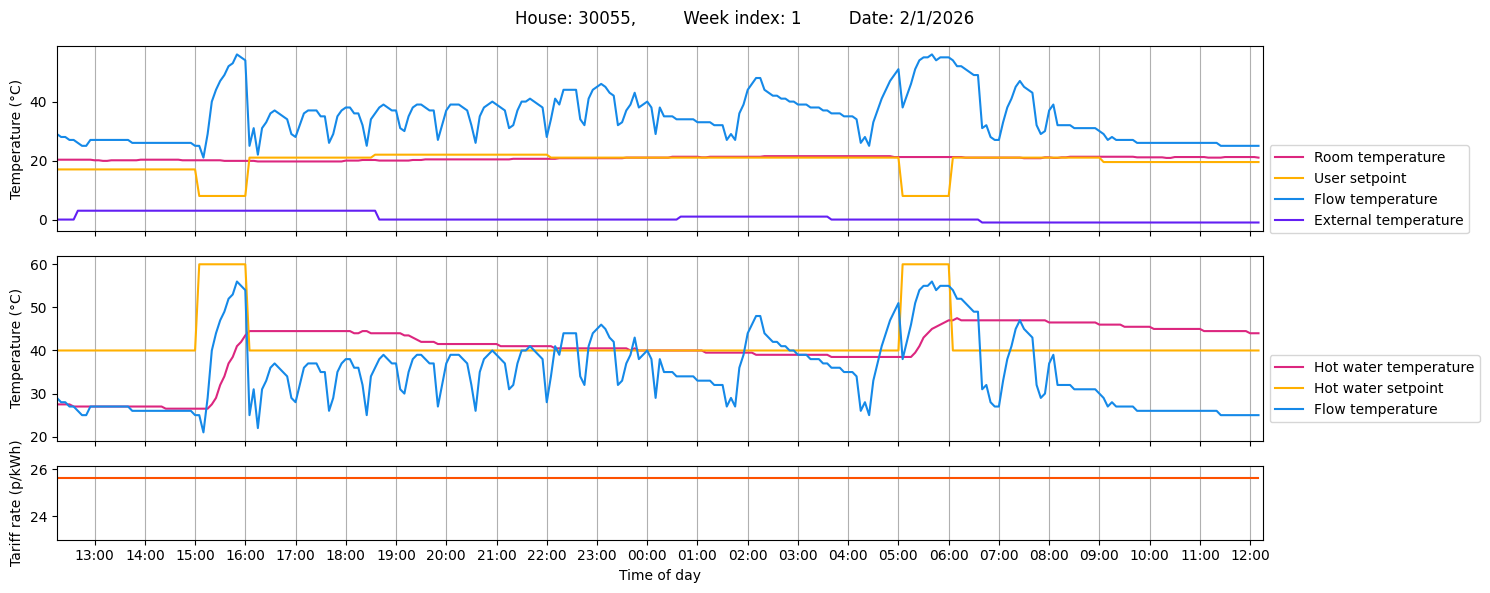

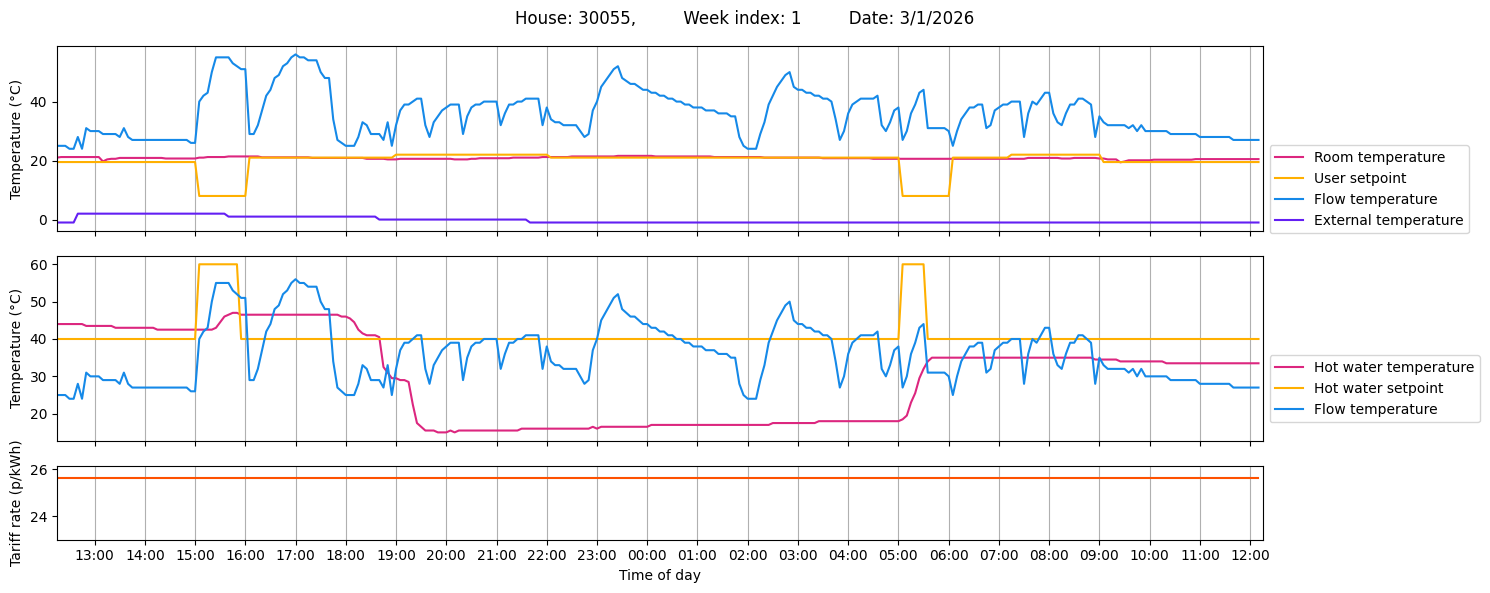

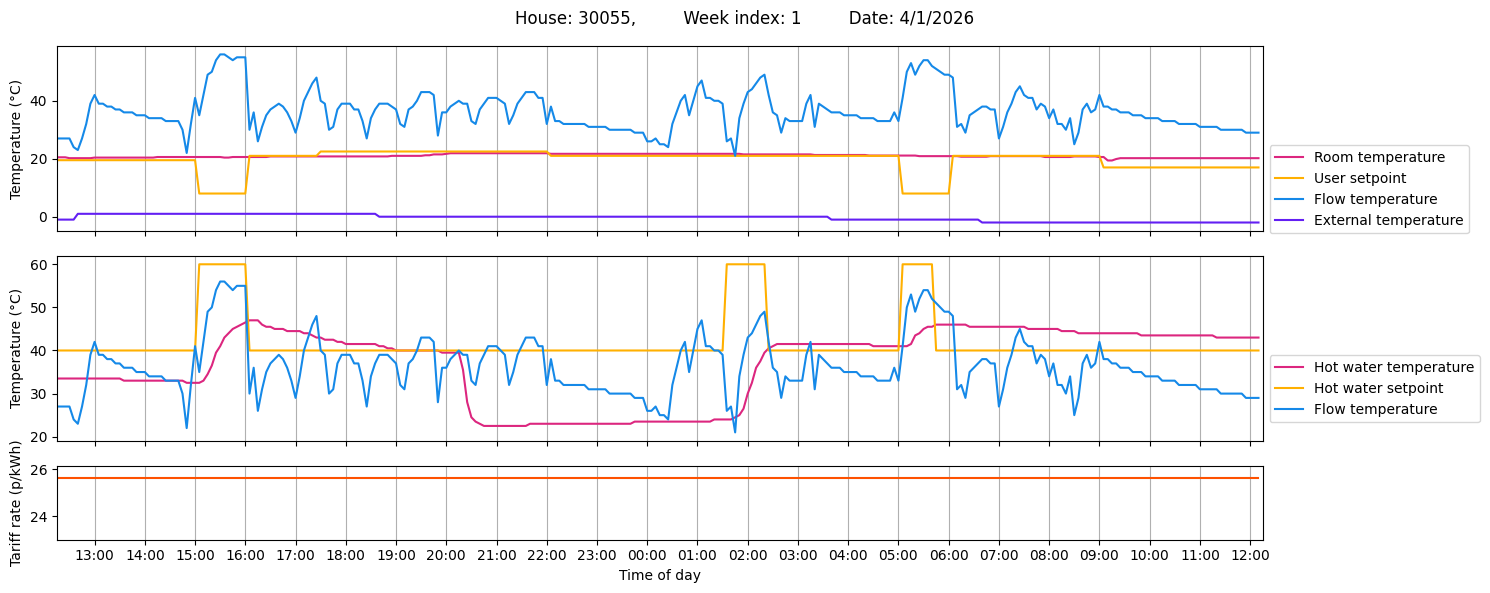

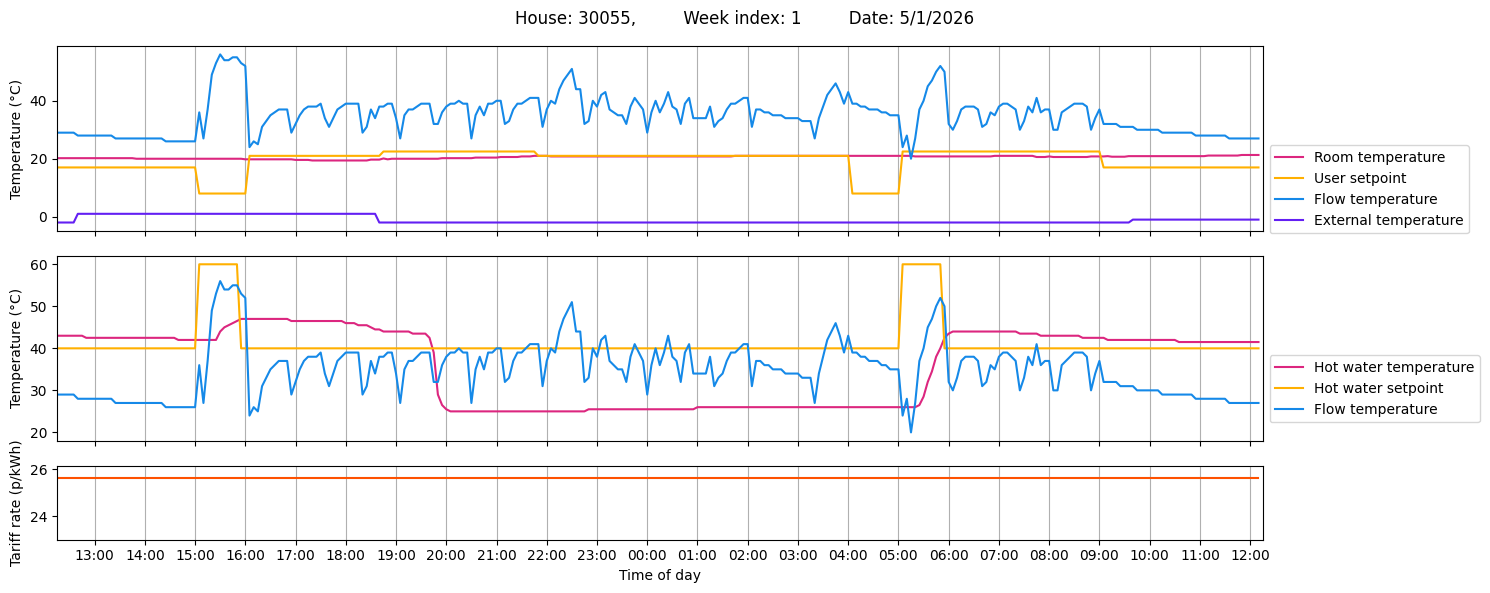

In [14]:
plot_temp_data(house_df, house_id, False, 1)